# DFT AM Modulation

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText

from scipy.signal import chirp, spectrogram, windows
from scipy.fftpack import fft, ifft, fftfreq, fftshift, ifftshift
from scipy.io.wavfile import write 


In [4]:
Fs = 2000 #                    % Sampling frequency
T = 1/Fs #                     % Sampling period
L = 4096 #                     % Length of signal
n = int(2**np.ceil(np.log2(L)))
f = np.linspace(0,1/2-1/n,n)*Fs #   % freq vector 

In [5]:
t = np.arange(L)*T #                % Time vector

f_sig1 = 20 #hz
f_sig2 = 300 #hz

message = np.cos(2*np.pi*f_sig1*t) + np.sin(2*np.pi*1.5*f_sig1*t - np.pi/4) 
carrier = np.cos(2*np.pi*f_sig2*t + np.pi/np.sqrt(2)) 

# modulated signal
x3 = carrier * (1 + message)/2
# demodulated signal
x4 = x3*carrier

In [6]:
# Compute FFTs of various signals
X1 = fft(message)
X2 = fft(carrier)
X3 = fft(x3)
X4 = fft(x4)

X1_plot = fftshift(X1)/n
X2_plot = fftshift(X2)/n
X3_plot = fftshift(X3)/n
X4_plot = fftshift(X4)/n

xf = fftfreq(n, 1/Fs)
xf_plot = fftshift(xf)

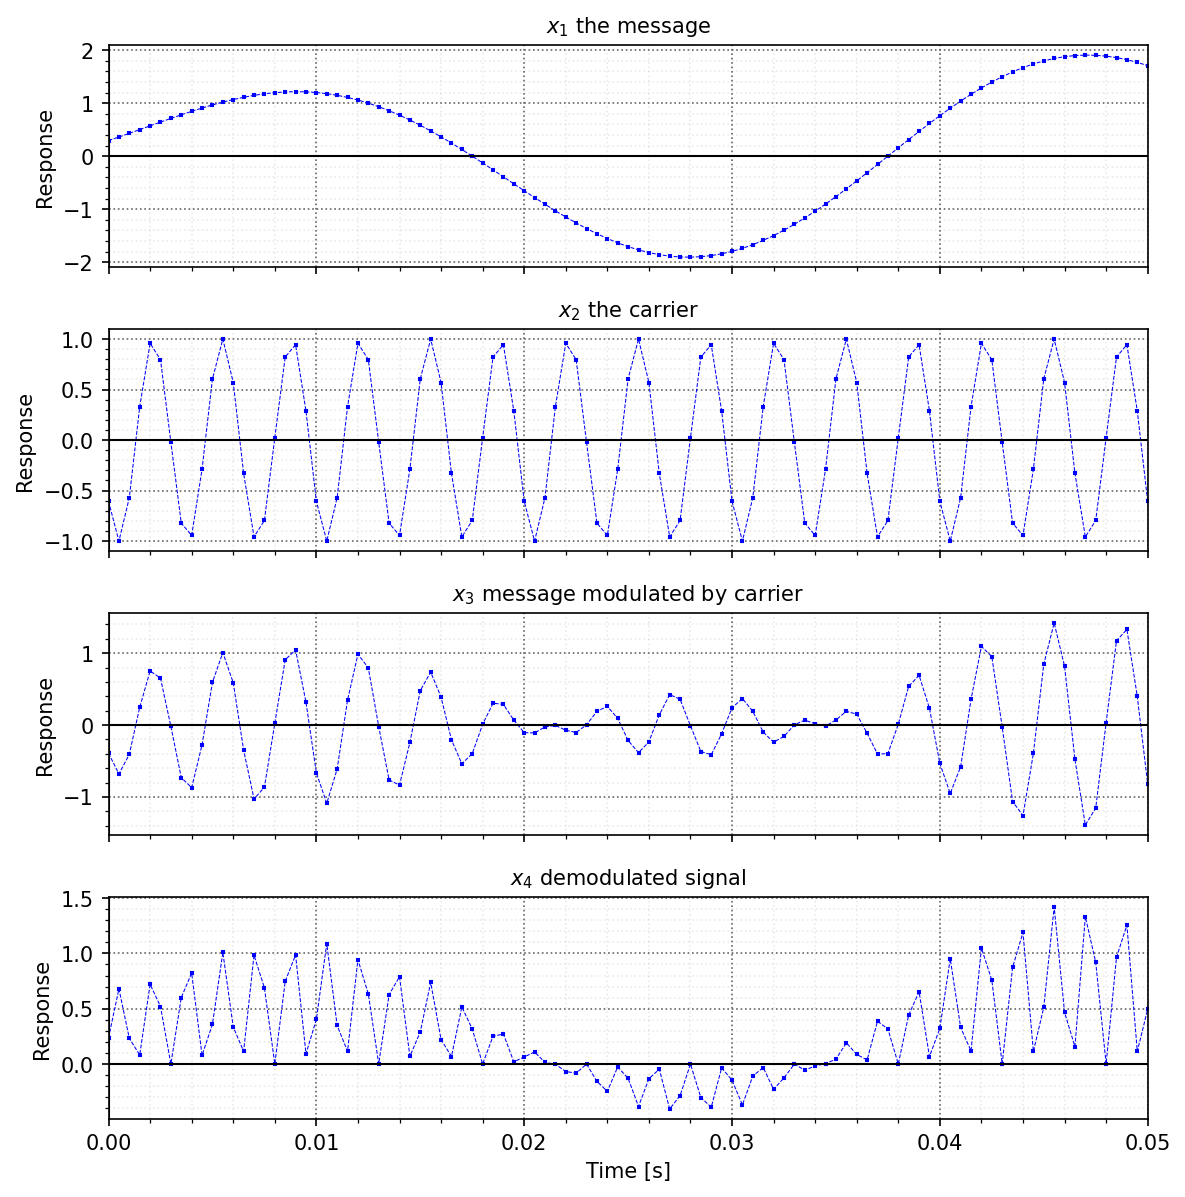

In [7]:
fig, ax = plt.subplots(4,1, figsize=(8,8), dpi=150,sharex=True)
fig.tight_layout(pad=2)
ax[0].plot(t, message,'bs--',label='with 4096 pts',lw=0.5,ms=1)
ax[1].plot(t, carrier,'bs--',label='with 4096 pts',lw=0.5,ms=1)
ax[2].plot(t, x3,'bs--',label='with 4096 pts',lw=0.5,ms=1)
ax[3].plot(t, x4,'bs--',label='with 4096 pts',lw=0.5,ms=1)
titles=['$x_1$ the message','$x_2$ the carrier','$x_3$ message modulated by carrier','$x_4$ demodulated signal']
ax[3].set_xlabel('Time [s]')
for ii in np.arange(4):
    ax[ii].set_ylabel('Response')
    ax[ii].set_title(titles[ii])
    bm.nicegrid(ax[ii])
    ax[ii].set_xlim([0, .05])
fig.savefig('./figs/T8_emessage1_1.pdf',format='pdf', dpi=300)

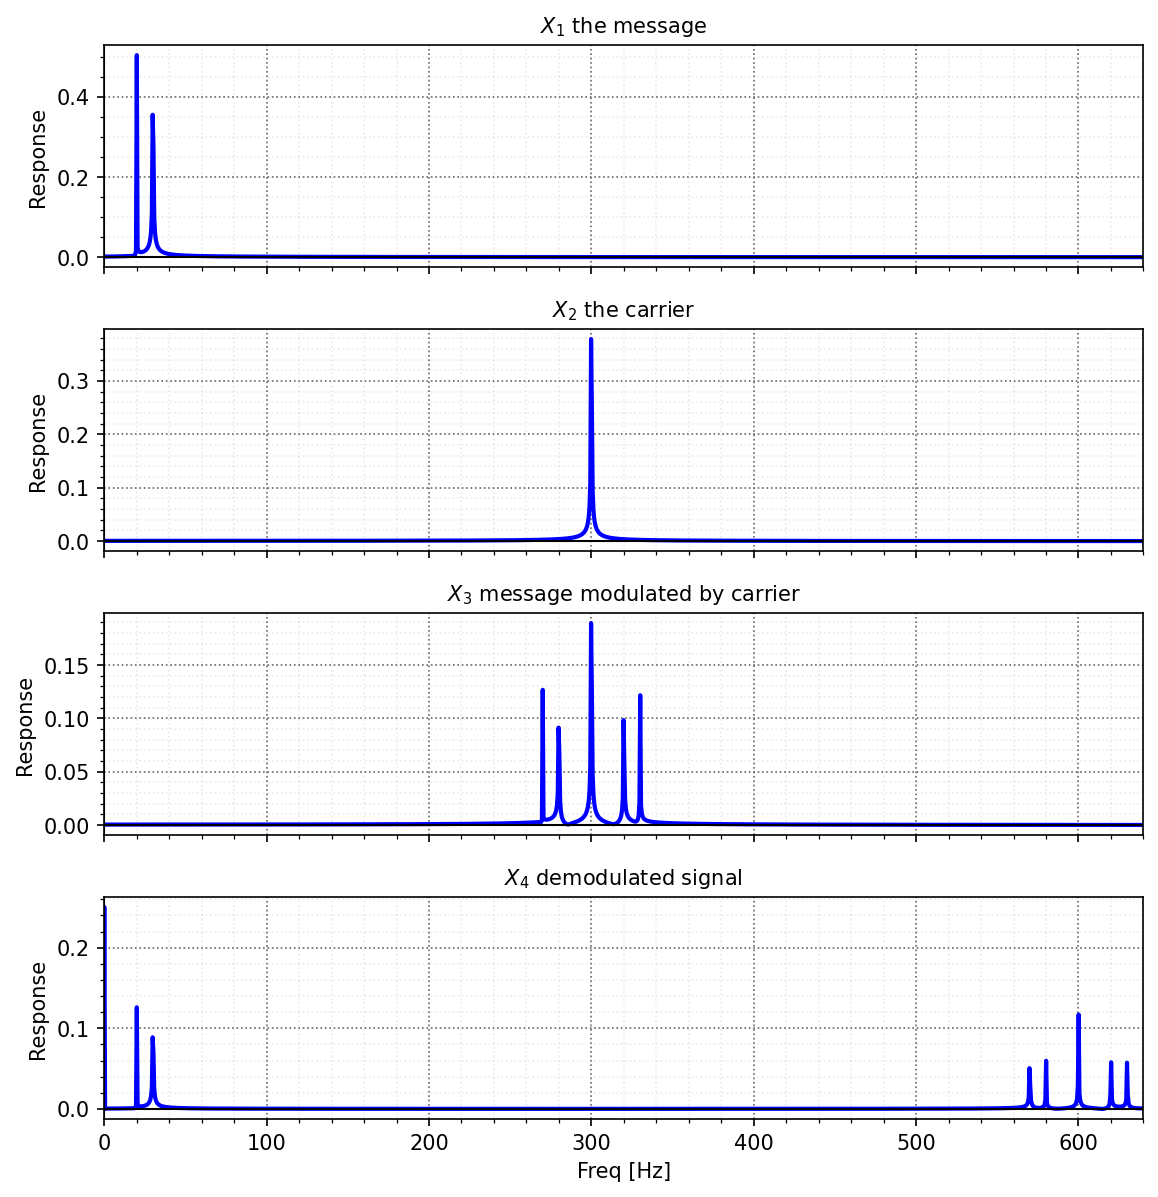

In [8]:
fig, ax = plt.subplots(4,1, figsize=(8,8), dpi=150,sharex=True)
fig.tight_layout(pad=2)
ax[0].plot(xf_plot, np.abs(X1_plot),'b-',label='$|X_1|$')
ax[1].plot(xf_plot, np.abs(X2_plot),'b-',label='$|X_2|$')
ax[2].plot(xf_plot, np.abs(X3_plot),'b-',label='$|X_3|$')
ax[3].plot(xf_plot, np.abs(X4_plot),'b-',label='$|X_4|$')
titles=['$X_1$ the message','$X_2$ the carrier','$X_3$ message modulated by carrier','$X_4$ demodulated signal']
ax[3].set_xlabel('Freq [Hz]')
for ii in np.arange(4):
    ax[ii].set_ylabel('Response')
    ax[ii].set_title(titles[ii])
    bm.nicegrid(ax[ii])
ax[3].set_xlim([0, 2*(f_sig2+f_sig1)])
    
fig.savefig('./figs/T8_emessage1_2.pdf',format='pdf', dpi=300)
plt.show()